In [5]:
import os 

from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv

### initialize model

In [7]:
load_dotenv()

api_key= os.getenv("GEMINI_API_KEY")
model = init_chat_model(model="gemini-2.5-flash-lite",api_key=api_key,model_provider="google_genai")

### define the state

In [11]:
class BlogState(TypedDict):
    title : str
    outline: str 
    content: str
    evaluate: str

### define nodes

In [19]:
def create_outline(state: BlogState) -> BlogState:

    # fetch the title
    title = state['title']
    
    # call llm to generate outline
    prompt = f"Generate a detailed outline for a blog on this topic - {title}"
    outline = model.invoke(prompt).content
    
    # update the state
    state['outline'] = outline

    return state


def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title -{title} using the following outline\n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content

    return state


def evaluate_blog(state: BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']
    content = state['content']

    prompt = f'Evalulate the this content -{content} which is written on this topic -{title} based on this outline -{outline}. Mark it in the range between 1 to 10'

    evaluate = model.invoke(prompt)

    state ['evaluate'] = evaluate

    return state

### Define graph and adding nodes

In [20]:
graph = StateGraph(BlogState)

# adding nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)
graph.add_node('evaluate_blog', evaluate_blog)

# adding edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', 'evaluate_blog')
graph.add_edge('evaluate_blog', END)

# compiling graph
workflow = graph.compile()

In [21]:
intial_state = {'title': 'Rise of AI in Bangladesh'}

final_state = workflow.invoke(intial_state)

print(final_state)

{'title': 'Rise of AI in Bangladesh', 'outline': '## Blog Outline: The Rise of AI in Bangladesh: From Potential to Progress\n\nThis outline provides a comprehensive structure for a blog post exploring the burgeoning AI landscape in Bangladesh. It aims to cover the current state, driving factors, challenges, opportunities, and future outlook of AI adoption and development within the country.\n\n---\n\n**Blog Title:** The Rise of AI in Bangladesh: From Potential to Progress\n\n**Target Audience:** Tech enthusiasts, policymakers, business leaders, students, and anyone interested in the technological advancements in Bangladesh.\n\n**Overall Tone:** Informative, optimistic, forward-looking, yet grounded in reality.\n\n---\n\n### **I. Introduction: A New Dawn for Bangladesh\'s Tech Scene**\n\n*   **A. Hook:** Start with a captivating statistic or a relatable anecdote about AI\'s growing presence in everyday life, then pivot to Bangladesh.\n    *   *Example Hook:* "Imagine a world where your 

In [22]:
print(final_state['outline'])

## Blog Outline: The Rise of AI in Bangladesh: From Potential to Progress

This outline provides a comprehensive structure for a blog post exploring the burgeoning AI landscape in Bangladesh. It aims to cover the current state, driving factors, challenges, opportunities, and future outlook of AI adoption and development within the country.

---

**Blog Title:** The Rise of AI in Bangladesh: From Potential to Progress

**Target Audience:** Tech enthusiasts, policymakers, business leaders, students, and anyone interested in the technological advancements in Bangladesh.

**Overall Tone:** Informative, optimistic, forward-looking, yet grounded in reality.

---

### **I. Introduction: A New Dawn for Bangladesh's Tech Scene**

*   **A. Hook:** Start with a captivating statistic or a relatable anecdote about AI's growing presence in everyday life, then pivot to Bangladesh.
    *   *Example Hook:* "Imagine a world where your doctor can diagnose diseases with unprecedented accuracy, your commut

In [23]:
print(final_state['content'])

## The Rise of AI in Bangladesh: From Potential to Progress

Imagine a world where your doctor can diagnose diseases with unprecedented accuracy, your commute is optimized by intelligent traffic systems, and your education is personalized to your unique learning style. This isn't science fiction; it's the promise of Artificial Intelligence, and it's rapidly taking root in Bangladesh. Once known primarily for its vibrant textiles and resilient spirit, Bangladesh is now charting a course towards becoming a significant player in the global technological landscape, with Artificial Intelligence (AI) at the forefront of this transformation.

At its core, AI refers to the simulation of human intelligence processes by machines, especially computer systems. These processes include learning, reasoning, and self-correction. For Bangladesh, a nation that has made remarkable strides in digitalization, the adoption of AI represents the next logical step in its journey towards economic prosperity and

In [25]:
print(final_state['evaluate'].content)

## Evaluation of the Content: "The Rise of AI in Bangladesh: From Potential to Progress"

This blog post is **excellent** and effectively addresses the outlined topic. It provides a comprehensive, well-structured, and optimistic yet realistic overview of the AI landscape in Bangladesh.

Here's a breakdown of its strengths and minor areas for consideration:

**Overall Score: 9.5/10**

**Strengths:**

*   **Strong Introduction and Hook:** The opening paragraph immediately grabs the reader's attention by painting a vivid picture of AI's potential and then grounding it in the Bangladeshi context. It clearly sets the stage for the blog's purpose.
*   **Clear and Logical Structure:** The content meticulously follows the provided outline, making it easy for readers to navigate and understand the different facets of AI in Bangladesh. Each section flows seamlessly into the next.
*   **Comprehensive Coverage:** The blog covers all the key areas identified in the outline, from current application

### Displaying the workflow

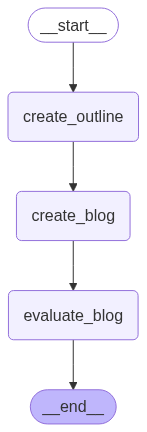

In [26]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())